In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import load_diabetes

In [3]:
df=load_diabetes()

In [4]:
print(df.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
x=df.data
y=df.target

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression, Ridge

In [9]:
LR=LinearRegression()

In [10]:
LR.fit(x_train,y_train)

LinearRegression()

In [11]:
y_pred=LR.predict(x_test)

In [12]:
from sklearn.metrics import r2_score

In [13]:
print(r2_score(y_test,y_pred))

0.4526027629719196


In [14]:
# pip install --upgrade scipy

In [15]:
RD=Ridge(alpha=10)

In [16]:
RD.fit(x_train,y_train)

Ridge(alpha=10)

In [17]:
y_pred=RD.predict(x_test)

In [18]:
print(r2_score(y_test,y_pred))

0.161225867509881


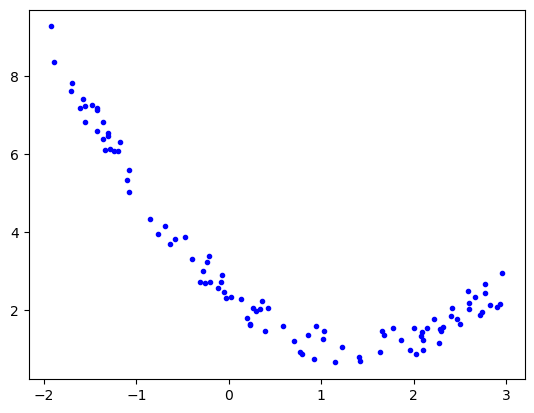

In [19]:
m=100
x1=5*np.random.rand(m,1)-2
x2=0.7*x1**2-2*x1+3-np.random.rand(m,1)
plt.plot(x1,x2,"b.")
plt.show()

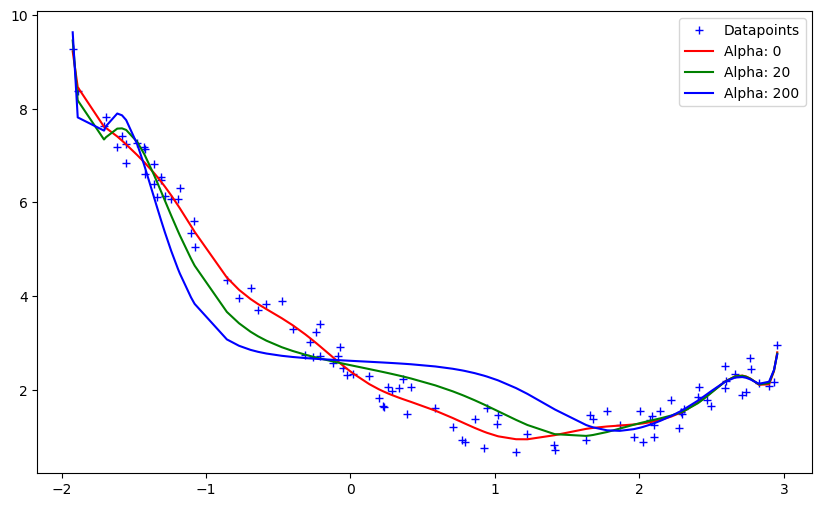

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

In [21]:
# Multiple Ridge Linear Regression

In [41]:
class meraRidge:
    def __init__(self,aplha=0.001):
        self.alpha=alpha
        self.intercept_=None
        self.coef_=None

    def fit(self,x_train,y_train):
        x_train=np.insert(x_train,0,1,axis=1)
        I=np.identity(x_train.shape[1])
        # I[0][0]=0
        result=np.linalg.inv(np.dot(x_train.T,x_train) + self.alpha*I).dot(x_train.T).dot(y_train)
        self.intercept_=result[0]
        self.coef_=result[1:]
        print(self.intercept_,self.coef_)

    def predict(self,x_test):
        return np.dot(x_test,self.coef_) + self.intercept_

In [42]:
MR=meraRidge(10)

In [43]:
MR.fit(x,y)

104.7398753894081 [ 1.48399002  0.31996749  4.68266769  3.51869174  1.66476185  1.35751476
 -3.1404906   3.41025043  4.50822907  3.03582431]


In [44]:
MR.predict(x_test)

array([105.27271699, 104.74378925, 105.16751023, 106.88407183,
       104.8944289 , 104.51840525, 106.12277872, 105.94906417,
       104.04085164, 104.58643994, 104.06808664, 104.27718942,
       103.06793987, 105.8758318 , 104.24553007, 104.28299844,
       106.03033011, 106.35435595, 104.64884653, 105.76753035,
       104.95266988, 104.12701765, 103.58018012, 105.44209393,
       104.39242122, 105.00657693, 105.1707936 , 105.1175094 ,
       103.04266298, 104.77306337, 105.08630001, 103.90243411,
       104.70137907, 105.36748839, 105.33127857, 105.4711475 ,
       104.65555104, 104.88675118, 105.37689718, 103.38867555,
       103.82107214, 104.33843792, 104.67426828, 105.34719439,
       105.00977241, 103.51320135, 103.5273989 , 103.62646126,
       103.28060041, 104.42757683, 104.00288313, 103.3339437 ,
       104.64661174, 104.04201349, 105.69785291, 104.24206535,
       104.21933568, 105.22120602, 103.97928952, 103.16092403,
       105.53153255, 104.89090829, 104.28239198, 104.44